# 02 — Evidence: why the optical temperature column is wrong (and only that column)

**File checked:** `data/raw/Analytical_Record_Creation_EE_60TPD_updated-2.xlsx`, sheet `result`. Every number below comes from this file. Row numbers are the **Excel row numbers**, so you can open the file and look at the same cells.

## Summary in plain words
1. The analytical record is **not one measurement system**. It is several sources joined together on the timestamp.
   - Most columns (gas, air, MB3, boosters, NCV) come from **machines** (DCS / energy meters), which write proper date-times.
   - The optical temperature comes from a **hand-typed log**, where the date and time are typed as text, such as `09/11/2025` and `3:00`.
2. When that text was turned into a date-time, **an Indian-style date `DD/MM/YYYY` was read as an American-style `MM/DD/YYYY`**.
   - `09/11/2025` (9 Nov) became **11 Sep**.
   - `13/11/2025` stayed correct, because there is no month 13. So **only days 1–12 move**.
3. In six months of 2026 the typed time had **no AM/PM**, so a 3 pm reading (`3:00`) was stored at **03:00**.
4. Because only the optical text dates were converted, **only the optical column lands at wrong times**. Everything else stays correct. The proofs below show this directly in the raw rows.

In [1]:
import sys; sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import data_prep as dp
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, INK2, MUTED, GRID, SURF = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURF, 'axes.facecolor': SURF, 'axes.edgecolor': MUTED,
    'axes.labelcolor': INK2, 'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 1.6, 'font.size': 10, 'axes.titlesize': 11, 'axes.titlecolor': INK,
    'legend.frameon': False, 'figure.dpi': 110})
pd.set_option('display.max_columns', 60); pd.set_option('display.max_colwidth', 60)
F = dp.AR_FILE
raw = pd.read_excel(F, sheet_name='result')
raw.insert(0, 'excel_row', raw.index + 2)           # row 1 is the header in Excel
OPT = 'Melter Optical Temperature'
short = {c: s for c, s in dp.AR_COLUMNS.items()}
print('rows in sheet:', len(raw), '| first data row = Excel row 2 | columns:', len(raw.columns) - 1)
print('Note: empty optical cells contain the text "null" in Excel; pandas reads them as missing (NaN).')

rows in sheet: 43624 | first data row = Excel row 2 | columns: 14
Note: empty optical cells contain the text "null" in Excel; pandas reads them as missing (NaN).


## 1. Where each column comes from, and why only optical can be mis-dated
| Column | Likely source | How its time is recorded |
|---|---|---|
| Melter gas flow, secondary air flow, bottom TC MB3 | DCS (tags `dcs_60_…`) | machine time stamp |
| Barrier booster, melter booster | energy meters / DB | machine time stamp |
| NCV meter | UEMS (MQTT) | machine time stamp |
| Draw (MB51), seed count, cullet % | SAP / lab, **one value per day** | a date only, no hour |
| **Melter optical temperature** | **hand-typed hourly log** | **typed text, e.g. `09/11/2025` + `3:00`** |

Only the last column has its date and hour as typed text that someone's code had to interpret. The tests below check whether the other columns were affected.

### Test A: in the duplicated rows, which columns differ?
If the joining step attached two optical readings to the same time stamp, the row is copied, and **every other column is copied unchanged**. So in the duplicated rows, only the optical column should differ.

In [2]:
dup = raw[raw.Timestamps.duplicated(keep=False)]
g = dup.groupby('Timestamps')
testA = pd.DataFrame({'time stamps that appear twice': len(g),
                      'of these, how many have different values in this column': [int((g[c].nunique(dropna=False) > 1).sum()) for c in raw.columns[2:]]},
                     index=raw.columns[2:])
testA

,time stamps that appear twice,"of these, how many have different values in this column"
BARRIER BOOSTER-52,5472,0
MELTER BOOSTER-51,5472,0
NCV Meter,5472,0
Cullet %,5472,0
Melter Optical Temperature,5472,5472
dcs_60_SecondaryAirFlowvalueFTSAFPVDB205DD92,5472,0
dcs_60_MelterGasflowvalueFTMGFPVDB202DD92,5472,0
dcs_60_ThermocoupleMelterBottom3TCMB3PVDB249DD572,5472,0
Air_Fuel_Ratio,5472,0
Seed Count,5472,0


**Result:** 5,472 time stamps appear twice. In **all** of them the 12 other columns are identical, and **only the optical temperature differs**. This is exactly what happens when a list with two optical readings for one time stamp is joined onto a table that has one row per time stamp.

### Test B: on the days optical is missing, are the other columns also missing?
If the plant had stopped recording on those days (power cut, PC down), all columns would have gaps. If only the optical column is empty, the optical readings exist but were moved somewhere else.

In [3]:
first = raw.groupby('Timestamps').first()
miss_days = ['2025-11-02', '2025-11-05', '2025-11-09', '2025-12-03', '2025-12-08', '2026-01-10', '2026-03-10', '2026-06-10', '2026-08-10']
testB = pd.DataFrame({c: [first.loc[d:d + ' 23:45', c].notna().mean() for d in miss_days] for c in raw.columns[2:]}, index=miss_days)
testB.columns = [short.get(c, c) for c in testB.columns]
(testB * 100).round(0).astype(int).astype(str) + '%'

,bb_kwh,mb_kwh,ncv,cullet_pct,opt_temp,sec_air,ng_scm,mb3_temp,afr,seed_count,seed_spec,draw_kg,sfc_record
2025-11-02,100%,100%,100%,100%,0%,100%,100%,100%,100%,100%,100%,100%,100%
2025-11-05,100%,100%,100%,100%,0%,100%,100%,100%,100%,100%,100%,100%,100%
2025-11-09,100%,100%,100%,100%,0%,100%,100%,100%,100%,100%,100%,100%,100%
2025-12-03,100%,100%,100%,100%,0%,100%,100%,100%,100%,100%,100%,100%,100%
2025-12-08,100%,100%,100%,100%,0%,100%,100%,100%,100%,100%,100%,100%,100%
2026-01-10,100%,100%,100%,100%,0%,100%,100%,100%,100%,100%,100%,100%,100%
2026-03-10,100%,100%,100%,100%,0%,100%,100%,100%,100%,100%,100%,100%,100%
2026-06-10,100%,100%,100%,100%,0%,100%,100%,100%,100%,100%,100%,100%,100%
2026-08-10,100%,100%,100%,100%,0%,100%,100%,100%,100%,100%,100%,100%,100%


**Result:** on these days every other column is 100% filled, and **only the optical column is 0%**. The furnace and the data system were running normally. The optical readings for these days exist, but they were stored under a different date.

## 2. The raw rows: what you will see in the Excel file
### Example 1: one time stamp, two rows (Excel rows 970 and 971)

In [4]:
ex1 = raw[raw.excel_row.isin([970, 971])].set_index('excel_row').T
ex1.columns = ['Excel row 970', 'Excel row 971']
ex1['same in both rows?'] = ['yes' if str(a) == str(b) else '<-- DIFFERENT' for a, b in zip(ex1.iloc[:, 0], ex1.iloc[:, 1])]
ex1

,Excel row 970,Excel row 971,same in both rows?
Timestamps,2025-09-11 02:00:00,2025-09-11 02:00:00,yes
BARRIER BOOSTER-52,111.0,111.0,yes
MELTER BOOSTER-51,57.2,57.2,yes
NCV Meter,0.0,0.0,yes
Cullet %,20,20,yes
Melter Optical Temperature,1575.0,1574.0,<-- DIFFERENT
dcs_60_SecondaryAirFlowvalueFTSAFPVDB205DD92,934.332902,934.332902,yes
dcs_60_MelterGasflowvalueFTMGFPVDB202DD92,77.656942,77.656942,yes
dcs_60_ThermocoupleMelterBottom3TCMB3PVDB249DD572,1319.29541,1319.29541,yes
Air_Fuel_Ratio,12.031544,12.031544,yes


Both rows are stamped **11 Sep 2025 02:00**, and all values are the same except the optical temperature (1575 vs 1574).

One of these is the real reading of 11 Sep 2025 02:00. The other was typed in the log as **`09/11/2025` 02:00** (9 Nov), but read as 11 Sep.

In [5]:
per_day = raw.groupby(raw.Timestamps.dt.normalize()).agg(rows_in_sheet=('excel_row', 'size'), optical_readings=(OPT, 'count'))
show = per_day.loc[pd.to_datetime(['2025-09-10', '2025-09-11', '2025-09-12', '2025-09-20', '2025-10-11', '2025-10-12',
                                   '2025-11-09', '2025-11-10', '2025-12-09', '2025-12-10'])]
show['expected rows'] = 96
show['what happened'] = ['normal', 'receives 9 Nov readings', 'receives 9 Dec readings', 'normal (control)',
                         'receives 10 Nov readings', 'receives 10 Dec readings',
                         'readings moved to 11 Sep', 'readings moved to 11 Oct', 'readings moved to 12 Sep', 'readings moved to 12 Oct']
show

,rows_in_sheet,optical_readings,expected rows,what happened
2025-09-10,96,96,96,normal
2025-09-11,148,148,96,receives 9 Nov readings
2025-09-12,160,160,96,receives 9 Dec readings
2025-09-20,96,96,96,normal (control)
2025-10-11,152,152,96,receives 10 Nov readings
2025-10-12,160,160,96,receives 10 Dec readings
2025-11-09,96,0,96,readings moved to 11 Sep
2025-11-10,96,0,96,readings moved to 11 Oct
2025-12-09,96,0,96,readings moved to 12 Sep
2025-12-10,96,0,96,readings moved to 12 Oct


A normal day has 96 rows (24 h × 4). The days that **receive** swapped readings have up to 160 rows: extra copies, one per extra optical reading. The days that **lose** their readings have 96 rows but no optical value. The receiving date is always the losing date with day and month exchanged.

### Example 2: optical stops at exactly 06:00 on 1 Nov 2025, everything else continues

In [6]:
ex2 = raw[(raw.Timestamps >= '2025-11-01 05:15') & (raw.Timestamps <= '2025-11-01 06:30')].set_index('excel_row')
ex2.columns = ['Timestamps'] + [short.get(c, c) for c in ex2.columns[1:]]
ex2

,Timestamps,bb_kwh,mb_kwh,ncv,cullet_pct,opt_temp,sec_air,ng_scm,mb3_temp,afr,seed_count,seed_spec,draw_kg,sfc_record
excel_row,,,,,,,,,,,,,,
6151,2025-11-01 05:15:00,110.0,87.8,9340.0,17,1574.0,962.813403,78.983775,1319.842179,12.190015,13,30.0 each,59443.0,1530.279253
6152,2025-11-01 05:30:00,109.0,87.9,9431.0,17,1574.0,962.685620,83.598725,1319.955492,11.515554,13,30.0 each,59443.0,1530.279253
6153,2025-11-01 05:45:00,108.0,87.9,9519.0,17,1574.0,963.548437,79.425134,1319.775486,12.131531,13,30.0 each,59443.0,1530.279253
6154,2025-11-01 06:00:00,109.0,87.9,9426.0,17,NaN,963.510321,79.441684,1319.822191,12.128523,13,30.0 each,59443.0,1530.279253
6155,2025-11-01 06:15:00,108.0,87.9,9534.0,17,NaN,963.701030,83.717339,1319.702103,11.511367,13,30.0 each,59443.0,1530.279253
6156,2025-11-01 06:30:00,107.0,87.9,9606.0,17,NaN,962.932378,78.385184,1319.775510,12.284622,13,30.0 each,59443.0,1530.279253


The optical log runs on a **shift day from 06:00 to 06:00**. The log page dated `01/11/2025` covers 1 Nov 06:00 to 2 Nov 05:00. Read as MM/DD, it became **12 Jan 2025**, which is before this file starts, so those readings were dropped entirely. That's why the optical gap starts at exactly 06:00, while gas, air, MB3, boosters and NCV carry on without a break.

## 3. How the swap happens: reproduced with the same kind of conversion
The cell below converts typed log dates into date-times the way most software does by default (month first), and then the correct way (day first).

In [7]:
typed = pd.Series(['09/11/2025 02:00', '10/11/2025 02:00', '13/11/2025 02:00', '01/12/2025 14:00', '09/12/2025 14:00', '25/12/2025 14:00'])
demo = pd.DataFrame({'typed in the log (DD/MM/YYYY)': typed,
                     'what the operator meant': pd.to_datetime(typed, dayfirst=True, format='mixed'),
                     'read month-first (default)': pd.to_datetime(typed, format='mixed')})
demo['result'] = np.where(demo['what the operator meant'] == demo['read month-first (default)'], 'correct',
                 np.where(demo['read month-first (default)'] < pd.Timestamp('2025-09-01'), 'moved before Sep 2025 -> lost', 'moved to another date -> duplicate'))
demo

,typed in the log (DD/MM/YYYY),what the operator meant,read month-first (default),result
0,09/11/2025 02:00,2025-11-09 02:00:00,2025-09-11 02:00:00,moved to another date -> duplicate
1,10/11/2025 02:00,2025-11-10 02:00:00,2025-10-11 02:00:00,moved to another date -> duplicate
2,13/11/2025 02:00,2025-11-13 02:00:00,2025-11-13 02:00:00,correct
3,01/12/2025 14:00,2025-12-01 14:00:00,2025-01-12 14:00:00,moved before Sep 2025 -> lost
4,09/12/2025 14:00,2025-12-09 14:00:00,2025-09-12 14:00:00,moved to another date -> duplicate
5,25/12/2025 14:00,2025-12-25 14:00:00,2025-12-25 14:00:00,correct


This reproduces the pattern in the file exactly:
- days 1–12 are read with day and month exchanged
- days 13–31 can't be exchanged (there is no month 13), so they stay correct
- an exchanged date before 1 Sep 2025 is outside the file, so those readings are **lost**
- an exchanged date inside the period **lands on top of** another day's readings, which creates duplicates

## 4. Proof 1: the swap explains every missing optical day
### Picture: one row per day, one column per hour
Colour = number of optical readings stored in that hour (white = 0, blue = 1, orange = 2).

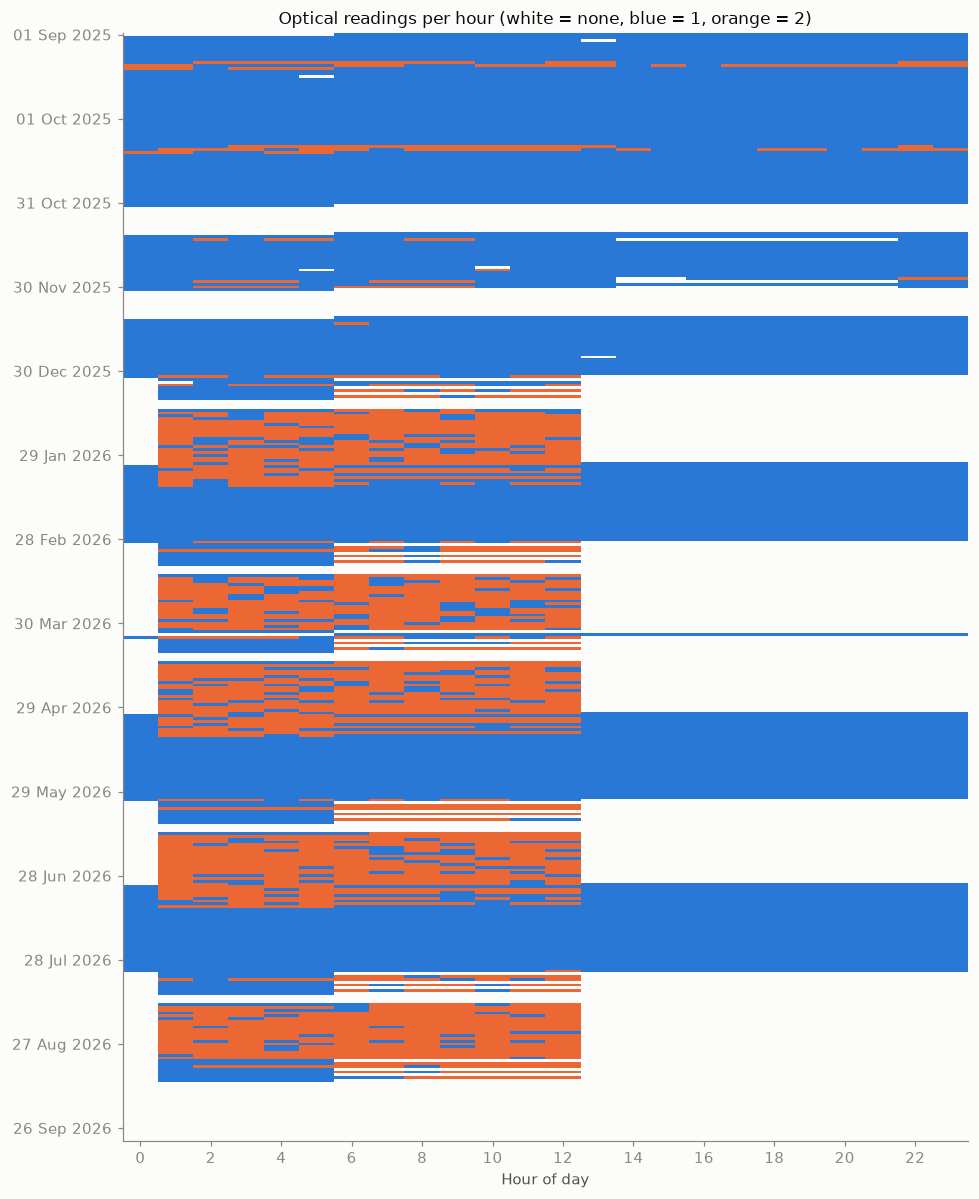

In [8]:
slot = raw.groupby('Timestamps')[OPT].agg(n_rows='size', n_read='count')
slot['hour'] = slot.index.hour
hr = slot.groupby([slot.index.normalize(), 'hour'])['n_rows'].max().where(
        slot.groupby([slot.index.normalize(), 'hour'])['n_read'].max() > 0, 0).unstack()
from matplotlib.colors import ListedColormap
fig, ax = plt.subplots(figsize=(9, 11))
ax.imshow(hr.values, aspect='auto', cmap=ListedColormap([SURF, BLUE, ORANGE]), vmin=0, vmax=2, interpolation='nearest')
yt = np.arange(0, len(hr), 30); ax.set_yticks(yt); ax.set_yticklabels([hr.index[i].strftime('%d %b %Y') for i in yt])
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel('Hour of day'); ax.grid(False)
ax.set_title('Optical readings per hour (white = none, blue = 1, orange = 2)')
plt.tight_layout(); plt.show()

- **White horizontal bands** = days whose optical readings were moved away (days 1–10/11 of Nov 2025, Dec 2025, and several 2026 months).
- **Orange/white blocks in 2026** = the 12-hour clock (section 5): hours 01–12 doubled, hours 13–23 empty.
- The last white block (from 9 Sep 2026) is the end of the optical data in this file.

### Test: predict where each missing day's readings went, then check
For each fully missing day (06:00–06:00 shift day), exchange its day and month:
- if that date is **inside** the file, it must contain duplicate optical readings
- if it is **outside**, the readings are lost and nothing can be checked

In [9]:
slot['shift_day'] = (slot.index - pd.Timedelta(hours=6)).normalize()
day = slot.groupby('shift_day').agg(have=('n_read', lambda s: (s > 0).sum()), dup=('n_rows', lambda s: (s > 1).sum()))
day = day[(day.index >= '2025-09-01') & (day.index <= '2026-09-30')]
start, end, TAIL = day.index.min(), day.index.max(), pd.Timestamp('2026-09-09')
missing = day[(day.have == 0) & (day.index < TAIL)]
rows = []
for dte in missing.index:
    sw = pd.Timestamp(year=dte.year, month=dte.day, day=dte.month) if dte.day <= 12 else None
    inside = sw is not None and start <= sw <= end
    rows.append({'missing shift-day': dte.date(), 'typed as': dte.strftime('%d/%m/%Y'),
                 'read as (month-first)': None if sw is None else sw.date(),
                 'inside the file?': 'yes' if inside else 'no -> lost',
                 'duplicates found on that date': (int(day.dup.get(sw, 0)) if inside else '-')})
proof = pd.DataFrame(rows)
proof

,missing shift-day,typed as,read as (month-first),inside the file?,duplicates found on that date
0,2025-11-01,01/11/2025,2025-01-11,no -> lost,-
1,2025-11-02,02/11/2025,2025-02-11,no -> lost,-
2,2025-11-03,03/11/2025,2025-03-11,no -> lost,-
3,2025-11-04,04/11/2025,2025-04-11,no -> lost,-
4,2025-11-05,05/11/2025,2025-05-11,no -> lost,-
5,2025-11-06,06/11/2025,2025-06-11,no -> lost,-
6,2025-11-07,07/11/2025,2025-07-11,no -> lost,-
7,2025-11-08,08/11/2025,2025-08-11,no -> lost,-
8,2025-11-09,09/11/2025,2025-09-11,yes,40
9,2025-11-10,10/11/2025,2025-10-11,yes,52


In [10]:
ins = proof[proof['inside the file?'] == 'yes']
print('Fully missing optical days:', len(proof), '-> with day-of-month <= 12:', sum(pd.to_datetime(proof['missing shift-day']).dt.day <= 12))
print('Predicted target date inside the file:', len(ins), '-> target actually has duplicates:', (ins['duplicates found on that date'] > 0).sum())
targets = set(pd.to_datetime(ins['read as (month-first)']))
ctrl = day[(day.index.day <= 12) & ~day.index.isin(targets) & ~day.index.isin(missing.index) & (day.index < '2026-01-01')]
print('Control (2025, other day<=12 dates): %d of %d carry duplicates (%.0f%%)' % ((ctrl.dup > 0).sum(), len(ctrl), 100*(ctrl.dup > 0).mean()))
ctrl_all = day[(day.index.day <= 12) & ~day.index.isin(targets) & ~day.index.isin(missing.index) & (day.index < TAIL)]
rate = (ctrl_all.dup > 0).mean()
print('Chance of 10 out of 10 by luck, using the highest control rate (%.0f%%): %.1e' % (100*rate, rate ** len(ins)))

Fully missing optical days: 36 -> with day-of-month <= 12: 36
Predicted target date inside the file: 10 -> target actually has duplicates: 10
Control (2025, other day<=12 dates): 3 of 24 carry duplicates (12%)
Chance of 10 out of 10 by luck, using the highest control rate (48%): 6.6e-04


**Result:**
- All 36 missing days have day-of-month ≤ 12; no day 13–31 is ever missing.
- **Every** missing day whose exchanged date falls inside the file (10 of 10) has duplicates on exactly that exchanged date.
- Other day ≤ 12 dates have duplicates much less often (about 1 in 8 in 2025).
- The chance of this being random is below 0.1%.

## 5. Proof 2: 12-hour clock in six months of 2026
If AM/PM is missing, a reading typed `3:00` at 3 pm is stored at **03:00**. In an affected month:
- hours 13–23 should be empty
- hours 01–12 should carry two readings in about half the slots

In [11]:
s = slot.copy(); s['month'] = s.index.to_period('M')
pm, am = s[s.hour >= 13], s[(s.hour >= 1) & (s.hour <= 12)]
by_m = pd.DataFrame({'optical filled, 13-23 h': pm.groupby('month').n_read.apply(lambda x: (x > 0).mean()),
                     'optical filled, 01-12 h': am.groupby('month').n_read.apply(lambda x: (x > 0).mean()),
                     'two readings, 01-12 h': am.groupby('month').n_rows.apply(lambda x: (x > 1).mean())})
other = raw.groupby('Timestamps').first()
other = other[other.index.hour >= 13]
by_m['gas flow filled, 13-23 h'] = other['dcs_60_MelterGasflowvalueFTMGFPVDB202DD92'].notna().groupby(other.index.to_period('M')).mean()
q_tmp = dp.clean_15min(with_crown=False)
by_m['12-h clock month (rule)'] = by_m.index.isin(dp.ampm_months(q_tmp))
(by_m.drop(columns='12-h clock month (rule)') * 100).round(0).astype(int).astype(str).add('%').join(by_m['12-h clock month (rule)'])

,"optical filled, 13-23 h","optical filled, 01-12 h","two readings, 01-12 h","gas flow filled, 13-23 h",12-h clock month (rule)
month,,,,,
2025-09,100%,98%,5%,100%,False
2025-10,100%,100%,6%,100%,False
2025-11,59%,66%,5%,100%,False
2025-12,67%,68%,0%,100%,False
2026-01,0%,83%,55%,100%,True
2026-02,100%,100%,20%,100%,False
2026-03,0%,83%,56%,99%,True
2026-04,3%,81%,54%,98%,True
2026-05,100%,100%,19%,100%,False


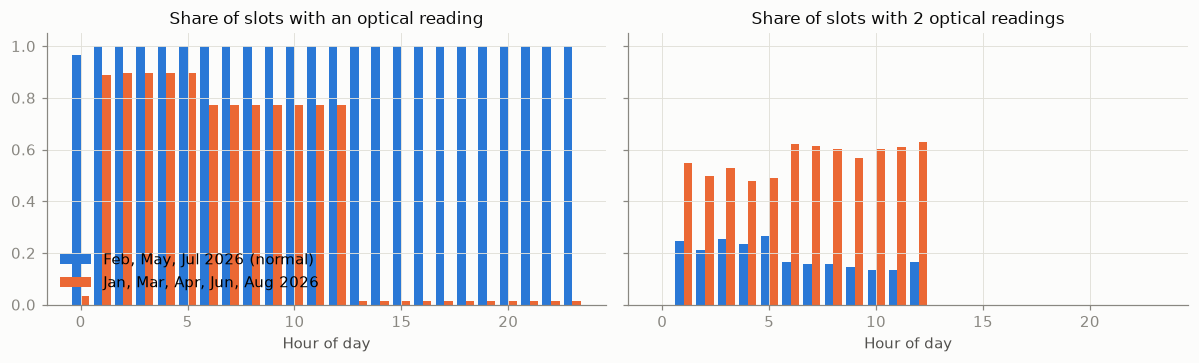

In [12]:
ok = s[s.month.isin([pd.Period('2026-02'), pd.Period('2026-05'), pd.Period('2026-07')])]
bad = s[s.month.isin([pd.Period(m) for m in ['2026-01', '2026-03', '2026-04', '2026-06', '2026-08']])]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for a_, fn, ttl in [(ax[0], lambda x: (x.n_read > 0).mean(), 'Share of slots with an optical reading'), (ax[1], lambda x: (x.n_rows > 1).mean(), 'Share of slots with 2 optical readings')]:
    a_.bar(np.arange(24) - 0.2, ok.groupby('hour').apply(fn), width=0.4, color=BLUE, label='Feb, May, Jul 2026 (normal)')
    a_.bar(np.arange(24) + 0.2, bad.groupby('hour').apply(fn), width=0.4, color=ORANGE, label='Jan, Mar, Apr, Jun, Aug 2026')
    a_.set_title(ttl); a_.set_xlabel('Hour of day')
ax[0].legend(loc='lower left'); plt.tight_layout(); plt.show()

### Example 3: raw rows of 20 Mar 2026: 06:00 and 12:45 hold two optical readings; from 13:00 optical is empty while gas, MB3 and NCV continue

In [13]:
ex3 = raw[raw.Timestamps.isin(pd.to_datetime(['2026-03-20 06:00', '2026-03-20 12:45', '2026-03-20 13:00', '2026-03-20 15:00', '2026-03-20 21:00']))]
ex3 = ex3[['excel_row', 'Timestamps', OPT, 'dcs_60_MelterGasflowvalueFTMGFPVDB202DD92', 'dcs_60_ThermocoupleMelterBottom3TCMB3PVDB249DD572', 'NCV Meter']]
ex3.columns = ['excel_row', 'Timestamps', 'optical', 'ng_scm', 'mb3_temp', 'ncv']
ex3.set_index('excel_row')

,Timestamps,optical,ng_scm,mb3_temp,ncv
excel_row,,,,,
21146,2026-03-20 06:00:00,1574.0,76.696987,1317.515323,10026.0
21147,2026-03-20 06:00:00,1575.0,76.696987,1317.515323,10026.0
21196,2026-03-20 12:45:00,1574.0,79.974071,1319.088794,10085.0
21197,2026-03-20 12:45:00,1575.0,79.974071,1319.088794,10085.0
21198,2026-03-20 13:00:00,NaN,74.898453,1318.902077,10090.0
21206,2026-03-20 15:00:00,NaN,73.979877,1318.055348,10126.0
21230,2026-03-20 21:00:00,NaN,73.759200,1320.335523,10162.0


**Result:**
- In Jan, Mar, Apr, Jun, Aug and Sep 2026, the optical column is empty from 13:00 to 23:00, while the gas flow in the same rows is 100% filled.
- The 01:00–12:00 slots carry two optical readings: the morning one and the afternoon/evening one typed without "PM".
- In Feb, May and Jul 2026 (and all of 2025) all 24 hours are filled normally. (Sep 2026 looks low overall because the optical data ends on 9 Sep.) So those months' logs were typed or saved in a different format.
- Daily averages in the affected months are still fine (the readings stay on the right day); only the hour is wrong.

## 6. Typing errors (also only in the hand-typed column)

In [14]:
bad_v = raw.loc[raw[OPT].notna() & ~raw[OPT].between(1550, 1600), ['excel_row', 'Timestamps', OPT]]
bad_v.groupby(OPT).agg(first_excel_row=('excel_row', 'min'), first_time=('Timestamps', 'min'), rows=('excel_row', 'size'))

,first_excel_row,first_time,rows
Melter Optical Temperature,,,
1473.0,35894,2026-07-23 07:00:00,4
1475.0,10542,2025-12-16 01:00:00,8
1476.0,11062,2025-12-21 11:00:00,4
1674.0,3258,2025-10-03 12:00:00,4
2576.0,3082,2025-10-01 16:00:00,4
15722.0,8658,2025-11-27 02:00:00,4
15757.0,5342,2025-10-23 19:00:00,4


These are keying errors of ~1575: an extra digit (15757), 1↔2 (2576), 5↔4 (1475, 1674). The machine-recorded columns contain nothing like this.

Rule: optical values outside 1,550–1,600 °C → missing.

## 7. One other column issue: draw doubled on two month-start days
This is a different kind of error (not dates). On 1 Oct 2025 and 1 Jun 2026 the daily draw is about twice the normal value, probably two SAP entries added together. The cleaning code halves it.

*Verification only:* the client workbook's SAP draw is used here to check the halved value; it is not used to fill data.

In [15]:
d_raw = raw.groupby(raw.Timestamps.dt.normalize())['MB51_Quantity_KG (Draw)'].first()
ref = d_raw.rolling(7, center=True, min_periods=3).median()
flag = d_raw[d_raw > 1.6 * ref]
base = dp.load_baseline_daily()
pd.DataFrame({'record draw (kg)': flag, 'median of surrounding week': ref[flag.index], 'ratio': (flag / ref[flag.index]).round(2),
              'halved': flag / 2, 'client SAP draw (check only)': base.base_draw_kg.reindex(flag.index)})

,record draw (kg),median of surrounding week,ratio,halved,client SAP draw (check only)
Timestamps,,,,,
2025-10-01,106204.0,55178.0,1.92,53102.0,53102
2026-06-01,115858.0,57807.0,2.00,57929.0,57929


## 8. What we do about it, and what to ask the plant
| Problem | Rule in `src/data_prep.py` | Effect |
|---|---|---|
| Day/month swap (log dates with day 1–12) | `opt_day_ok = False` on days 1–12 that carry duplicates or < 50% readings | daily optical mean used only on trustworthy days |
| 12-hour clock (6 months of 2026) | `ampm_months()` detects the months from the data; `opt_hour_ok = False` there and on duplicate slots | hour-by-hour optical isn't used in those months; the hourly crown signal is the TC MC3 thermocouple (clean DCS data) |
| Typing errors | outside 1,550–1,600 °C → missing | – |
| Draw doubled | halved automatically, `draw_fixed` flag | matches SAP exactly |

**Live use is not affected.** The operator types the current optical reading directly into the recommender, so there's no date conversion.

**Ask the plant / analytics team:**
1. Send the original optical log (the typed sheet) with dates as `YYYY-MM-DD` and a 24-hour clock. With it, the history can be repaired instead of dropped.
2. In the script that builds the analytical record, read the optical date with `dayfirst=True` (or an explicit `%d/%m/%Y %H:%M` format) and require a 24-hour time.

In [16]:
q = dp.clean_15min(); d = dp.build_daily(q)
print('Days with trustworthy daily optical mean:', int(d.opt_day_ok.sum()), 'of', len(d))
print('15-min slots with trustworthy optical hour:', int(q.opt_hour_ok.sum()), 'of', len(q))

Days with trustworthy daily optical mean: 255 of 395
15-min slots with trustworthy optical hour: 17080 of 37920
